In [21]:
import pandas as pd

# Load TRMM
trmm = pd.read_csv("C:/Users/priya/PycharmProjects/Coastal-prediction/dataset/rainfall_trmm.csv")

# Load GPM
gpm = pd.read_csv("C:/Users/priya/PycharmProjects/Coastal-prediction/dataset/rainfall_gpm.csv")

# Standardize column names
trmm.columns = ["Date", "Rainfall"]
gpm.columns = ["Date", "Rainfall"]

# Convert Date column to datetime
trmm["Date"] = pd.to_datetime(trmm["Date"])
gpm["Date"] = pd.to_datetime(gpm["Date"])

# Combine both datasets
rainfall = pd.concat([trmm, gpm])

# Sort by date
rainfall = rainfall.sort_values("Date")

# Remove duplicates if any
rainfall = rainfall.drop_duplicates()

# Remove negative rainfall
rainfall["Rainfall"] = rainfall["Rainfall"].clip(lower=0)

rainfall

,Date,Rainfall
0,1998-01-02,0.010306
1,1998-01-03,0.023861
2,1998-01-04,0.000000
3,1998-01-05,0.000000
4,1998-01-06,0.000000
...,...,...
3920,2025-09-26,8.059369
3921,2025-09-27,6.688069
3922,2025-09-28,16.828831
3923,2025-09-29,24.443644


In [22]:
# Read semicolon-separated txt file
sea = pd.read_csv("C:/Users/priya/PycharmProjects/Coastal-prediction/dataset/sealevel_chennai.txt", sep=";", header=None)

In [23]:
#The sealevel data doesn't contain any columns so we have to add it manually
sea.columns = ["Decimal_Year", "Sea_Level_mm", "Flag", "Quality"]

In [24]:
sea.head()

,Decimal_Year,Sea_Level_mm,Flag,Quality
0,1916.0417,6897,0,0
1,1916.1250,6833,0,0
2,1916.2083,6806,0,0
3,1916.2917,6879,0,0
4,1916.3750,6979,0,0


In [25]:
#Sometimes numbers have spaces. Remove them.
sea["Decimal_Year"] = sea["Decimal_Year"].astype(str).str.strip()
sea["Sea_Level_mm"] = sea["Sea_Level_mm"].astype(str).str.strip()

In [26]:
#Convert the data into numeric values
sea["Decimal_Year"] = pd.to_numeric(sea["Decimal_Year"], errors="coerce")
sea["Sea_Level_mm"] = pd.to_numeric(sea["Sea_Level_mm"], errors="coerce")

In [27]:
sea["Sea_Level_mm"].unique()

array([  6897,   6833,   6806,   6879,   6979,   7046,   6992,   6937,
         7062,   7123,   7196,   7077,   6958,   6900,   6882,   6888,
         6922,   6870,   6952,   6998,   7080,   7278,   7071,   7040,
         6845,   6766,   6739,   6925,   6912,   6830,   6812,   6961,
         7028,   7235,   6918,   6787,   6790,   6781,   6982,   7031,
         6909,   6943,   7251,   7150,   7016,   6839,   6876,   6970,
         6931,   6915,   7068,   7004, -99999,   6987,   7151,   7292,
         7084,   6984,   6926,   6883,   6889,   6938,   7002,   6917,
         6911,   7030,   7145,   7020,   6920,   6929,   6841,   6831,
         6944,   7011,   7005,   7240,   7231,   7215,   7027,   6975,
         6950,   6956,   7100,   6993,   7200,   7304,   7097,   6932,
         6895,   7023,   6959,   6914,   6953,   7087,   7161,   7060,
         6853,   6902,   7033,   7048,   7118,   7057,   6927,   6838,
         6835,   6789,   6942,   6990,   6916,   6973,   7104,   7287,
      

In [28]:
sea["Sea_Level_mm"] = sea["Sea_Level_mm"].replace(-99999, pd.NA)

In [29]:
#drop missing rows
sea = sea.dropna(subset=["Sea_Level_mm"])

In [30]:
#The data contains years in decimal in the format 1987.04175 which resembles 1987 the decimal represents Jan month
sea["Year"] = sea["Decimal_Year"].astype(int)

In [31]:
sea["Decimal_Part"] = sea["Decimal_Year"] - sea["Year"]

In [32]:
sea["Month"] = (sea["Decimal_Part"] * 12 + 1).round().astype(int)

In [33]:
sea["Date"] = pd.to_datetime(dict(year=sea["Year"], month=sea["Month"], day=1))

In [34]:
#This code simply have only the necessary columns for the analysis
sea = sea[["Date", "Sea_Level_mm"]]

In [35]:
sea.head()
sea.tail()

,Date,Sea_Level_mm
1284,2023-02-01,7301
1290,2023-08-01,7142
1291,2023-08-01,7052
1292,2023-09-01,7069
1294,2023-12-01,7253


In [36]:
sea["Date"].min()
sea["Date"].max()

Timestamp('2023-12-01 00:00:00')

In [37]:
sea = sea.sort_values("Date")
sea = sea.reset_index(drop=True)
sea

,Date,Sea_Level_mm
0,1916-02-01,6897
1,1916-02-01,6833
2,1916-03-01,6806
3,1916-05-01,6879
4,1916-06-01,6979
...,...,...
812,2023-02-01,7301
813,2023-08-01,7142
814,2023-08-01,7052
815,2023-09-01,7069


In [38]:
#merge both rainfall and sealevel data
merged = pd.merge(rainfall_monthly, sea, on="Date", how="inner")

NameError: name 'rainfall_monthly' is not defined

In [53]:
merged.head()
merged.shape

(271, 3)

In [54]:
merged.corr()

,Date,Rainfall,Sea_Level_mm
Date,1.000000,0.225391,0.535720
Rainfall,0.225391,1.000000,0.189376
Sea_Level_mm,0.535720,0.189376,1.000000


In [56]:
merged = merged.sort_values("Date")
merged["Sea_Level_lag1"] = merged["Sea_Level_mm"].shift(-1)

In [57]:
merged[["Rainfall", "Sea_Level_lag1"]].corr()

,Rainfall,Sea_Level_lag1
Rainfall,1.000000,0.325484
Sea_Level_lag1,0.325484,1.000000


In [58]:
for lag in range(1, 7):
    merged[f"Sea_Level_lag{lag}"] = merged["Sea_Level_mm"].shift(-lag)
    corr = merged["Rainfall"].corr(merged[f"Sea_Level_lag{lag}"])
    print(f"Lag {lag} months: {corr}")

Lag 1 months: 0.3254842568284236
Lag 2 months: 0.26574825852062545
Lag 3 months: 0.17760435816723874
Lag 4 months: 0.07334972775526447
Lag 5 months: 0.025656643937406194
Lag 6 months: 0.00026353644836016673


In [59]:
merged["Rainfall_lag1"] = merged["Rainfall"].shift(1)
merged[["Rainfall_lag1", "Sea_Level_mm"]].corr()

,Rainfall_lag1,Sea_Level_mm
Rainfall_lag1,1.000000,0.325484
Sea_Level_mm,0.325484,1.000000


In [61]:
merged["Rain_3day"] = merged["Rainfall"].rolling(3).sum()
merged["Rain_7day"] = merged["Rainfall"].rolling(7).sum()

merged["Sea_lag1"] = merged["Sea_Level_mm"].shift(1)

In [62]:
merged = merged.dropna()

In [64]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

merged[["Rain_norm", "Sea_norm"]] = scaler.fit_transform(
    merged[["Rain_7day", "Sea_Level_mm"]]
)

In [65]:
merged["Flood_Risk_Index"] = (
    0.6 * merged["Rain_norm"] +
    0.4 * merged["Sea_norm"]
)

In [66]:
merged["Risk_Class"] = pd.qcut(
    merged["Flood_Risk_Index"],
    q=3,
    labels=["Low", "Medium", "High"]
)

In [87]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Features and target
X = merged[["Rainfall", "Rain_3day", "Rain_7day", "Sea_Level_mm", "Sea_lag1"]]
y = merged["Risk_Class"]
merged["Rain_Intensity"] = merged["Rain_3day"] / (merged["Rain_7day"] + 1)

# Time-based split (80% train, 20% test)
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# Improved RandomForest
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=4,
    random_state=42
)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[31  9]
 [ 0 12]]
              precision    recall  f1-score   support

        High       1.00      0.78      0.87        40
      Medium       0.57      1.00      0.73        12

    accuracy                           0.83        52
   macro avg       0.79      0.89      0.80        52
weighted avg       0.90      0.83      0.84        52



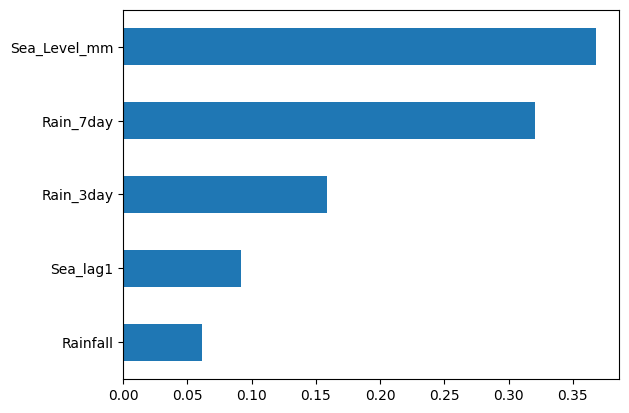

In [72]:
import matplotlib.pyplot as plt

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind="barh")
plt.show()

In [73]:
y_pred = model.predict(X_test)

print(y_pred[:10])

['Low' 'Low' 'Medium' 'Medium' 'Medium' 'Medium' 'High' 'High' 'Low'
 'Medium']


In [79]:
new_data = pd.DataFrame(
    [[120, 250, 400, 0.8, 0.75]],
    columns=["Rainfall", "Rain_3day", "Rain_7day", "Sea_Level_mm", "Sea_lag1"]
)

prediction = model.predict(new_data)

print("Predicted Flood Risk:", prediction[0])

Predicted Flood Risk: Low


In [80]:
latest = X.iloc[[-1]]   # last row

prediction = model.predict(latest)

print("Predicted Flood Risk for Last Day:", prediction[0])

Predicted Flood Risk for Last Day: High


In [82]:
proba = model.predict_proba(latest)

print("Class Probabilities:", proba)
print(model.classes_)

Class Probabilities: [[1. 0. 0.]]
['High' 'Low' 'Medium']


In [83]:
print(merged["Risk_Class"].value_counts())

Risk_Class
Low       87
Medium    86
High      86
Name: count, dtype: int64


In [84]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[15  0  1]
 [ 0 22  1]
 [ 0  0 13]]
              precision    recall  f1-score   support

        High       1.00      0.94      0.97        16
         Low       1.00      0.96      0.98        23
      Medium       0.87      1.00      0.93        13

    accuracy                           0.96        52
   macro avg       0.96      0.96      0.96        52
weighted avg       0.97      0.96      0.96        52



In [107]:
print(y_test.value_counts())

Risk_Class
High      40
Medium    12
Low        0
Name: count, dtype: int64


In [108]:
merged["Risk_Tomorrow"] = merged["Risk_Class"].shift(-1)
merged = merged.dropna(subset=["Risk_Tomorrow"])

In [109]:
from sklearn.ensemble import RandomForestClassifier

X = merged[["Rainfall", "Rain_3day", "Rain_7day", "Sea_Level_mm", "Sea_lag1"]]
y = merged["Risk_Tomorrow"]

# Time-based split
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        High       1.00      0.42      0.60        40
         Low       0.00      0.00      0.00         0
      Medium       0.23      0.50      0.32        12

    accuracy                           0.44        52
   macro avg       0.41      0.31      0.30        52
weighted avg       0.82      0.44      0.53        52



C:\Users\priya\PycharmProjects\Coastal-prediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\priya\PycharmProjects\Coastal-prediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\priya\PycharmProjects\Coastal-prediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{me